In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math as mt
from scipy.integrate import quad, dblquad
import sympy as sp

# **Punto 1**

**Lanzamiento de moneda**

Hallar la probabilidad de obtener entre 40 y 60 caras inclusive en 100 lanzamientos de una moneda. Compare los resultados entre una aproximación y el valor real.

Para ensayar la hipótesis de que una moneda está bien hecha, se toma la siguiente regla de decisión:

Se acepta la hipótesis si el número de caras en una serie de 100 lanzamientos se encuentra entre 40 y 60, ambos inclusive; de otro modo, se rechaza.

In [3]:
# Parametros de esta distribucion en específico


n = 100
p = 0.5
k_1 = 40
k_2 = 60

# definimos la función de densidad de probabilidad binomial
def binomial_pmf(k, n, p):
    return (mt.factorial(n) / (mt.factorial(k) * mt.factorial(n - k))) * (p ** k) * ((1 - p) ** (n - k))

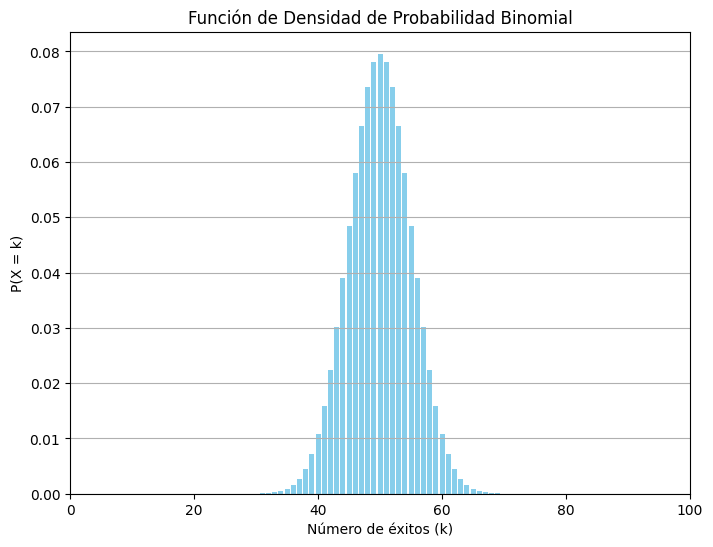

In [4]:
# grafica de la función de densidad de probabilidad binomial
k_values = np.arange(0, n + 1)
binomial_values = [binomial_pmf(k, n, p) for k in k_values]

plt.figure(figsize=(8, 6))
plt.bar(k_values, binomial_values, color='skyblue')
plt.title('Función de Densidad de Probabilidad Binomial')
plt.xlabel('Número de éxitos (k)')
plt.ylabel('P(X = k)')
plt.xlim(0, n)
plt.grid(axis='y')
plt.show()

In [5]:
P_interes = np.sum([binomial_pmf(k, n, p) for k in range(k_1, k_2)])
print(f"La probabilidad de obtener entre {k_1} y {k_2} éxitos es: {P_interes:.4f}")

La probabilidad de obtener entre 40 y 60 éxitos es: 0.9540


**a)** Hallar la probabilidad de rechazar la hipótesis, cuando en realidad es cierta.

**Sln:** Sabemos que al ser $np >> 100$ esto implíca que $X \sim N[x;\mu = np, \sigma^2 = np(1-p)]$. Asi, la normal estandar respectiva a $X$ (cantidad de exitos) es:

$$
Z = \frac{X - np}{\sqrt{np (1-p)}}
$$

In [6]:
def normal_pdf(x, mu, sigma2):
    sigma = np.sqrt(sigma2)
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

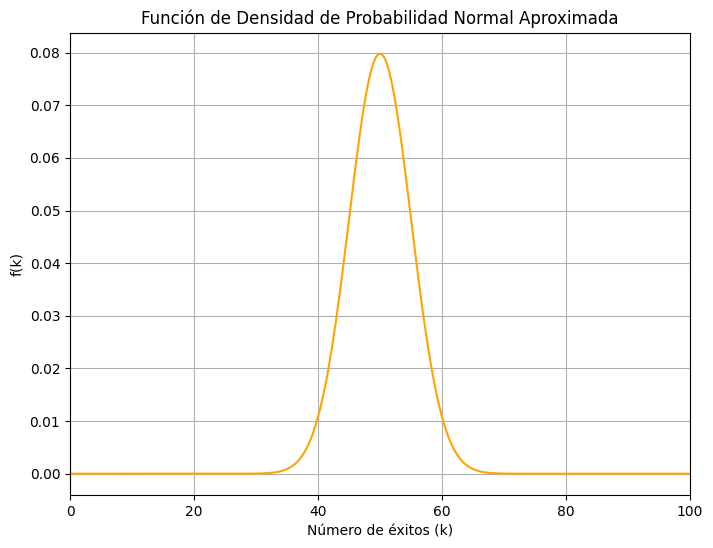

In [7]:
#grafica de la función de densidad de probabilidad normal respectiva a este problema

mu = n * p
sigma2 = n * p * (1 - p)

x_values = np.linspace(0, n, 1000)
normal_values = [normal_pdf(x, mu, sigma2) for x in x_values]

plt.figure(figsize=(8, 6))
plt.plot(x_values, normal_values, color='orange')
plt.title('Función de Densidad de Probabilidad Normal Aproximada')
plt.xlabel('Número de éxitos (k)')
plt.ylabel('f(k)')
plt.xlim(0, n)
plt.grid()
plt.show()


EN este problema tomamos como hipotesis nula $H_0: \text{ la moneda esta bien hecha}$ si se rechaza esta hipotesis aceptamos como cierta la hipotesis $H_a: \text{ la moneda no esta bien hecha}$ esto pasa si en 100 lanzamientos se dan menos de 40 o mas de 60 caras ($X$), esto es: 

$$
P(X \leq 40) + P( X \geq 60) = \alpha
$$

In [1]:
sigma2

NameError: name 'sigma2' is not defined

In [14]:
# Calculo de la probabilidad usando la aproximación normal

P_les_40 = quad(lambda x: normal_pdf(x, mu, sigma2), -np.inf, k_1)[0]
P_gre_60 = 1 - quad(lambda x: normal_pdf(x, mu, sigma2), -np.inf, k_2)[0]

P_interes_normal = P_les_40 + P_gre_60
print(f"La probabilidad de obtener de decir que la moneda esta sesgada y en realidad no lo este es del {P_interes_normal*100:.4f} %")


La probabilidad de obtener de decir que la moneda esta sesgada y en realidad no lo este es del 4.5500 %


**b)** Interpretar gráficamente la regla de decisión y el resultado del apartado (a).

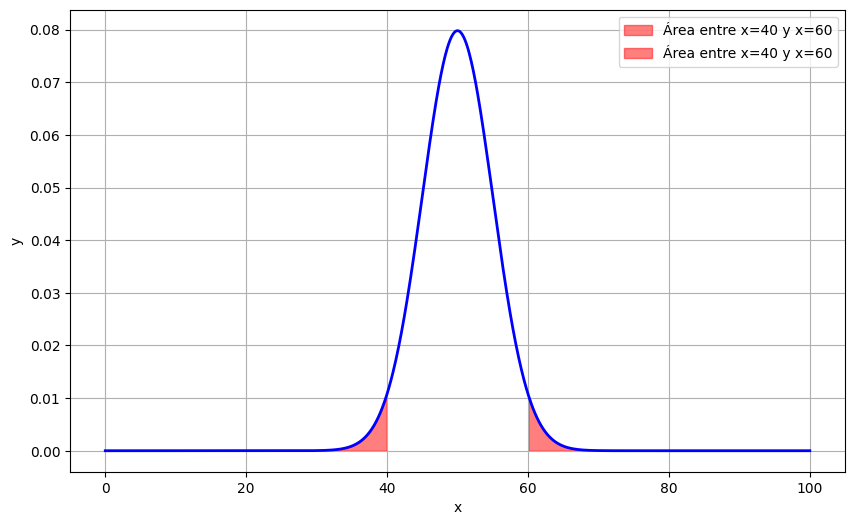

In [15]:
# Llenar solo entre x=2 y x=8
plt.figure(figsize=(10, 6))
plt.plot(x_values, normal_values , 'b-', linewidth=2)

# Llenar entre dos valores de x
mask1 = (x_values <= 40)
mask2 = (x_values >= 60)
plt.fill_between(x_values[mask1], np.array(normal_values)[mask1], alpha=0.5, color='red', label='Área entre x=40 y x=60')
plt.fill_between(x_values[mask2], np.array(normal_values)[mask2], alpha=0.5, color='red', label='Área entre x=40 y x=60')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

El área roja representa la probabilidad de que, al lanzar n veces la moneda, el número de caras sea mayor a 60 o menor a 40, y que esto ocurra por pura casualidad. Esto también representa la probabilidad de afirmar que la moneda está mal hecha cuando en realidad está bien hecha.

**c)** ¿Qué conclusiones se sacarían si en la muestra de 100 lanzamientos se obtuviesen 53 caras? ¿60 caras?

**respuesta:** La conclusión sería que basicamente se aprueba la hipotesis nula $H_0$


**d)** ¿Podrían ser erróneas las conclusiones de (c)? Explicar.

**Respuesta.** Si, podrian ser erroneas debido a que estamos asumiendo que para que una moneda este bien hecha, al lanzarla 100 veces, las veces que caiga una cara debe de ser un valor entre 40 y 50. Para esto tenemos que calcular la probabilidad de cometer un error de tipo 2. Es decir, la probabilidad de no negar $H_0$ y que $H_0$ sea falso.

**e)** ¿Cuál es la probabilidad de aceptar la hipótesis de que la moneda está bien hecha cuando la probabilidad real de cara es p = 0.7?

In [16]:
# si p = 0.7 en realidad la moneda esta sesgada, entonces la probabilidad de obtener entre 40 y 60 éxitos es:

p_sesgada = 0.7
mu_sesgada = n * p_sesgada
sigma2_sesgada = n * p_sesgada * (1 - p_sesgada)

P_interes_sesgada = quad(lambda x: normal_pdf(x, mu_sesgada, np.sqrt(sigma2_sesgada)), k_1, k_2)[0]

print(f"La probabilidad de obtener entre {k_1} y {k_2} éxitos con una moneda sesgada (p=0.7) es: {P_interes_sesgada}")

La probabilidad de obtener entre 40 y 60 éxitos con una moneda sesgada (p=0.7) es: 0.0


**Respuesta.** Basicamente nula la probabilidad.

## **Punto 2** 

**Elecciones.**

Dos partidos políticos, $G$ y $U$, han comenzado su campaña electoral en el país. Sea $p$ la proporción de todos los votantes potenciales que favorecen a $U$ sobre $G$. Considere probar $H0: p = 0.5$ contra $Ha: p \neq 0.5$, basado en una muestra aleatoria de 100 individuos. Sea el estadístico de prueba $X$ el número de la muestra que favorece a $U$, y $x$ el valor observado de $X$.

**a)**
Describa los errores tipo I y tipo II en este contexto.

### **b)**
Suponga que $x = 37$. ¿Qué valores de $X$ son igual o más contradictorios que éste con $H_0$?

### **c)**
¿Cuál es la distribución de probabilidades del estadístico de prueba $X$ cuando $H_0$ es cierto? Use esto para calcular la probabilidad de obtener un valor igual o más contradictorio a $H_0$ cuando éste es cierto (P-value) si $x = 37$.

### **d)**
Si se va a rechazar $H_0$ cuando P-value $\leq 0.056$, calcule la probabilidad de tener un error de tipo II cuando $p$ tiene valores de 0.4, 0.3, 0.6 y 0.7. [Ayuda: ¿A qué desigualdades que involucran a $x$ es equivalente P-value $> 0.056$]

### **e)**
Usando el procedimiento de prueba de (d), ¿qué concluiría si 37 de los 100 consultados favorecieran a U?

## **Punto 3**

**Consumo de alcohol**

Un estudio (hipotético) en la Universidad encontró que 51 estudiantes en una muestra de 462 se abstienen de consumir alcohol. ¿Estos resultados proporcionan suficiente evidencia para concluir que más del 10% de la población se abstiene de consumir alcohol? Realice la prueba de hipótesis apropiada.

In [17]:
# definamos los parametros obtenidos del muestreo

x = 51
n = 462
p_muestral = x / n

p_Hnula = 0.1     # hipotesis nula

Nuestra hipotesis nula será $H_0 : p = 0.1$ y $H_a: p > 0.1$. aceptando como cierta la hipotesis nula vemos que el estimador $\hat{p}$ sigue una distribucion normal de la forma:

$\hat{P} \sim N(\hat{p}, \mu = p_0, \sigma^2 = \frac{p(1-p)}{n})$

In [19]:
# parametros de la normal que sigue el estimador p_hat

mu_p_hat = p_Hnula
sigma2_p_hat = (p_Hnula * (1 - p_Hnula)) / n

normal_p_hat = lambda x: normal_pdf(x, mu_p_hat, sigma2_p_hat)

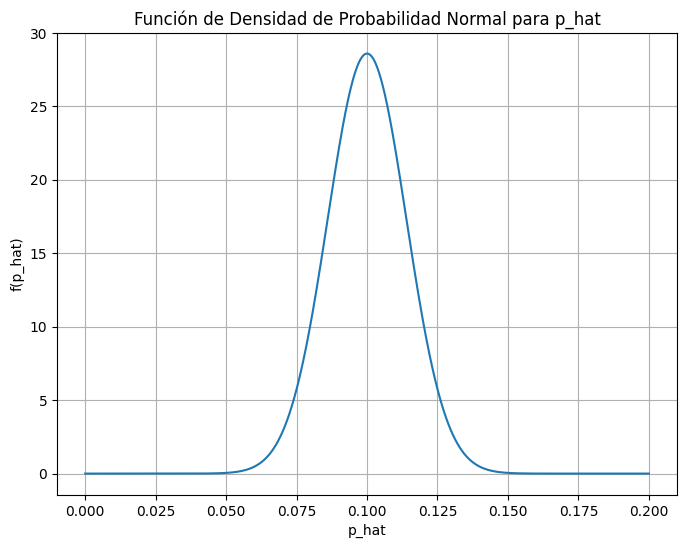

In [20]:
#grafica de la función de densidad de probabilidad normal respectiva a este problema
x_values_p_hat = np.linspace(0, 2*0.1, 1000)
normal_values_p_hat = [normal_p_hat(x) for x in x_values_p_hat]

plt.figure(figsize=(8, 6))
plt.plot(x_values_p_hat, normal_values_p_hat)
plt.title('Función de Densidad de Probabilidad Normal para p_hat')
plt.xlabel('p_hat')
plt.ylabel('f(p_hat)')
plt.grid()
plt.show()


Se tomará un nivel de significancia para esta prueba de hipotesis de $\alpha = 0.05$


Se deben de buscar un valor critico ($\hat{p}_c$) tal que $P(\hat{p}> \hat{p}_c) = 0.95$

In [22]:
condicion = 0.95 
xs = np.linspace(0, 0.2, 1000)

for i, x in enumerate(xs):
    area = quad(normal_p_hat, 0, x)[0]
    #print(f"Área bajo la curva desde 0 hasta {x:.4f}: {area:.4f}")
    if (abs((area - condicion)/condicion) < 1e-3):
        x_critico = x
        break

In [23]:
print(f"El valor crítico para un nivel de confianza del {condicion*100}% es: {x_critico}")

El valor crítico para un nivel de confianza del 95.0% es: 0.12292292292292292


Ahora calculemos la estimacion puntual de $p$ con los datos muestrales:

In [24]:
p_estimacion = p_muestral
print(f"El valor de p estimado a partir de la muestra es: {p_estimacion:.4f}")

El valor de p estimado a partir de la muestra es: 0.1104


**Conclusión** No se puede rechazar $H_0$ con los datos muestrales obtenidos por lo tanto, se rechaza que $p > 0.1$

In [25]:
(-p_Hnula + p_muestral)/np.sqrt(sigma2_p_hat)

np.float64(0.7443873683187759)

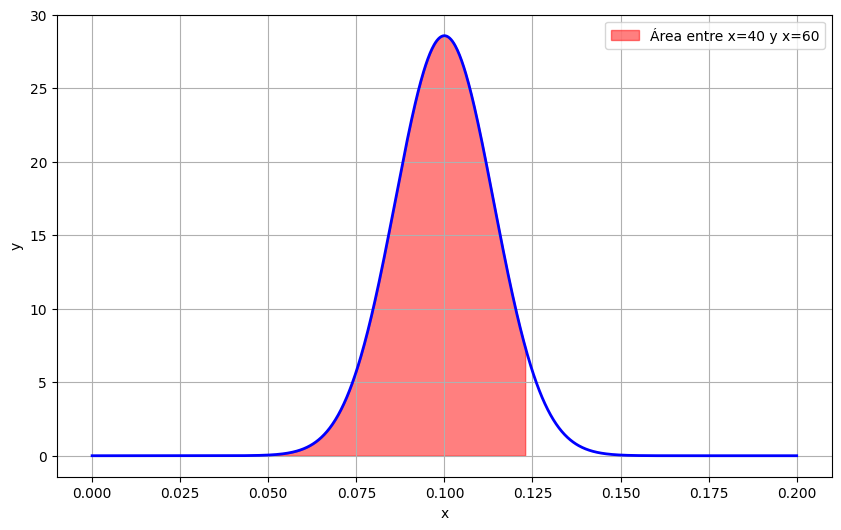

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(x_values_p_hat, normal_values_p_hat , 'b-', linewidth=2)

# Llenar entre dos valores de x
mask1 = (x_values_p_hat <= x_critico)

plt.fill_between(x_values_p_hat[mask1], np.array(normal_values_p_hat)[mask1], alpha=0.5, color='red', label='Área entre x=40 y x=60')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()